##### Import the libraries

In [18]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.seasonal import seasonal_decompose

##### Load the datasets

In [19]:
icu = pd.read_csv(r"C:\Users\balog\OneDrive\Documents\Olayemi\Intership\Hospital_Bed_Demand_Forecasting\Data\TimeSeries\ICU_TimeSeries.csv")
day_case = pd.read_csv(r"C:\Users\balog\OneDrive\Documents\Olayemi\Intership\Hospital_Bed_Demand_Forecasting\Data\TimeSeries\Day_Case_Unit_TimeSeries.csv")
general_a = pd.read_csv(r"C:\Users\balog\OneDrive\Documents\Olayemi\Intership\Hospital_Bed_Demand_Forecasting\Data\TimeSeries\General_Medicine_Ward_A_TimeSeries.csv")
general_b = pd.read_csv(r"C:\Users\balog\OneDrive\Documents\Olayemi\Intership\Hospital_Bed_Demand_Forecasting\Data\TimeSeries\General_Medicine_Ward_B_TimeSeries.csv")
oncology = pd.read_csv(r"C:\Users\balog\OneDrive\Documents\Olayemi\Intership\Hospital_Bed_Demand_Forecasting\Data\TimeSeries\Oncology_Ward_TimeSeries.csv")
ortho_a = pd.read_csv(r"C:\Users\balog\OneDrive\Documents\Olayemi\Intership\Hospital_Bed_Demand_Forecasting\Data\TimeSeries\Orthopaedics_Ward_A_TimeSeries.csv")
ortho_b = pd.read_csv(r"C:\Users\balog\OneDrive\Documents\Olayemi\Intership\Hospital_Bed_Demand_Forecasting\Data\TimeSeries\Orthopaedics_Ward_B_TimeSeries.csv")
cardiology = pd.read_csv(r"C:\Users\balog\OneDrive\Documents\Olayemi\Intership\Hospital_Bed_Demand_Forecasting\Data\TimeSeries\Cardiology_Ward_TimeSeries.csv")

In [20]:
icu.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3655 entries, 0 to 3654
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   hospital_id     3655 non-null   object 
 1   datetime        3655 non-null   object 
 2   ward            3655 non-null   object 
 3   occupied_beds   3655 non-null   float64
 4   staffed_beds    3655 non-null   float64
 5   occupancy_rate  3655 non-null   float64
dtypes: float64(3), object(3)
memory usage: 171.5+ KB


- Run the ADF test for every hospital

In [21]:
icu["hospital_id"].unique()

array(['HHN-BIR-01', 'HHN-EDI-01', 'HHN-LON-01', 'HHN-LON-02',
       'HHN-MAN-01'], dtype=object)

In [22]:
results = []

for hospital in icu["hospital_id"].unique():
    hospital_data = (icu[icu["hospital_id"] == hospital].sort_values("datetime").set_index("datetime"))
    adf = adfuller(hospital_data["occupied_beds"])
    results.append({"Hospital": hospital, "ADF Statistic": round(adf[0],4), "p-value": round(adf[1],4), 
                    "Stationary": "Yes" if adf[1] < 0.05 else "No"})

adf_results = pd.DataFrame(results)

print(f"ADF Test Results for ICU Unit Occupied Beds")
adf_results

ADF Test Results for ICU Unit Occupied Beds


,Hospital,ADF Statistic,p-value,Stationary
0,HHN-BIR-01,-5.9786,0.0,Yes
1,HHN-EDI-01,-7.0495,0.0,Yes
2,HHN-LON-01,-5.0783,0.0,Yes
3,HHN-LON-02,-6.5835,0.0,Yes
4,HHN-MAN-01,-8.1692,0.0,Yes


     All five hospitals have stationary bed occupancy data.
     P-values are below 0.05, confirming the results are statistically significant.
     Bed occupancy fluctuates around a stable average over time.
     The data is ready for time series forecasting.
     Since the data is already stationary, differencing may not be required, making models such as ARIMA(1,0,0) or ARIMA(2,0,0) good starting points for forecasting.

- Autocorrelation (ACF) for all hospitals

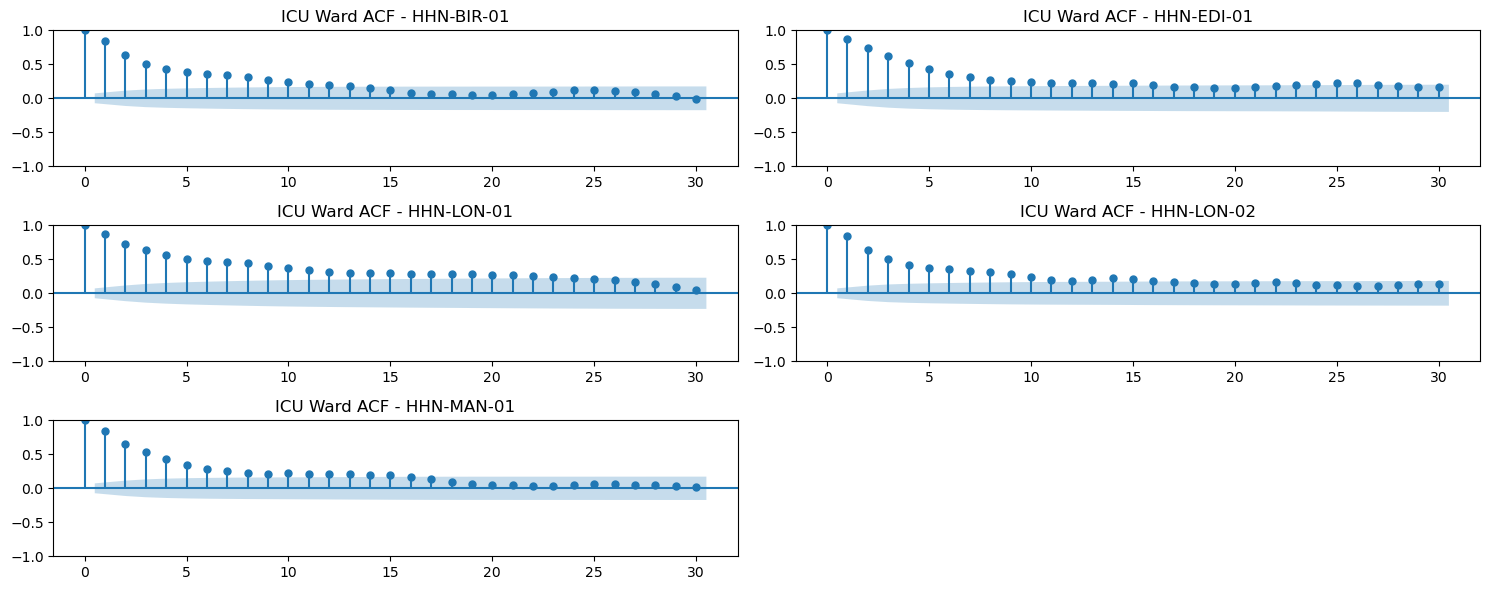

In [23]:
# Create subplots
fig, axes = plt.subplots(3, 2, figsize=(15, 6))
axes = axes.flatten()

# Loop through hospitals
for i, hospital in enumerate(sorted(icu["hospital_id"].unique())):

    hospital_data = (icu[icu["hospital_id"] == hospital].sort_values("datetime").set_index("datetime"))
    plot_acf(hospital_data["occupied_beds"], lags=30,ax=axes[i])
    axes[i].set_title(f"ICU Ward ACF - {hospital}")

# Remove unused subplot
fig.delaxes(axes[-1])

plt.tight_layout()
plt.show()

     Hospital bed occupancy has a strong relationship with previous days.
     The data is not random and follows clear patterns.
     A trend is present, so the data should be made stationary before forecasting.
     There is evidence of a weekly (7-day) pattern in bed occupancy.
     All hospitals show similar behaviour, making a common forecasting model suitable.

- PACF for all hospitals

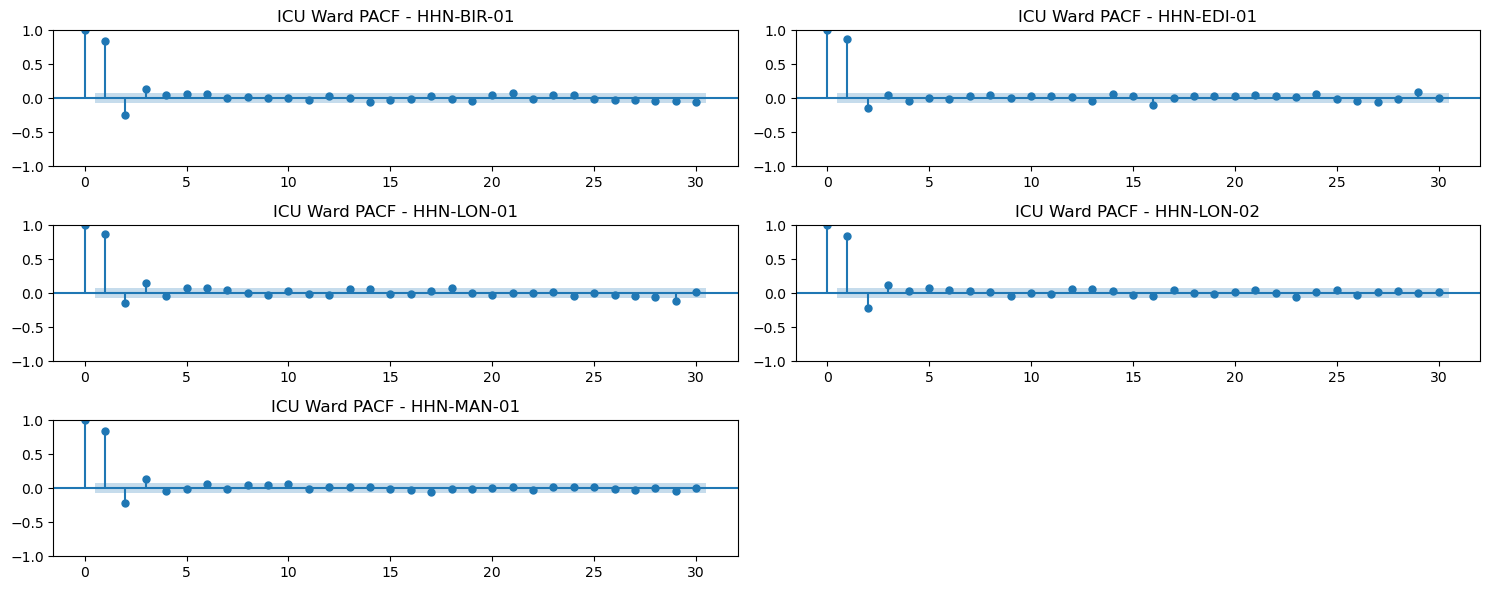

In [24]:
fig, axes = plt.subplots(3, 2, figsize=(15, 6))
axes = axes.flatten()

for i, hospital in enumerate(sorted(icu["hospital_id"].unique())):

    hospital_data = (icu[icu["hospital_id"] == hospital].sort_values("datetime").set_index("datetime"))
    plot_pacf(hospital_data["occupied_beds"], lags=30, ax=axes[i], method="ywm")
    axes[i].set_title(f"ICU Ward PACF - {hospital}")
fig.delaxes(axes[-1])
plt.tight_layout()
plt.show()

     Yesterday's bed occupancy has the strongest effect on today's occupancy.
     The previous 1–2 days are the most important for prediction.
     Data older than 2 days has little direct influence.
     All hospitals show similar PACF patterns.
     The results suggest an Autoregressive (AR) forecasting model, such as ARIMA(1,1,0) or ARIMA(2,1,0), is a suitable starting point.

- Seasonal Decomposition for all hospitals

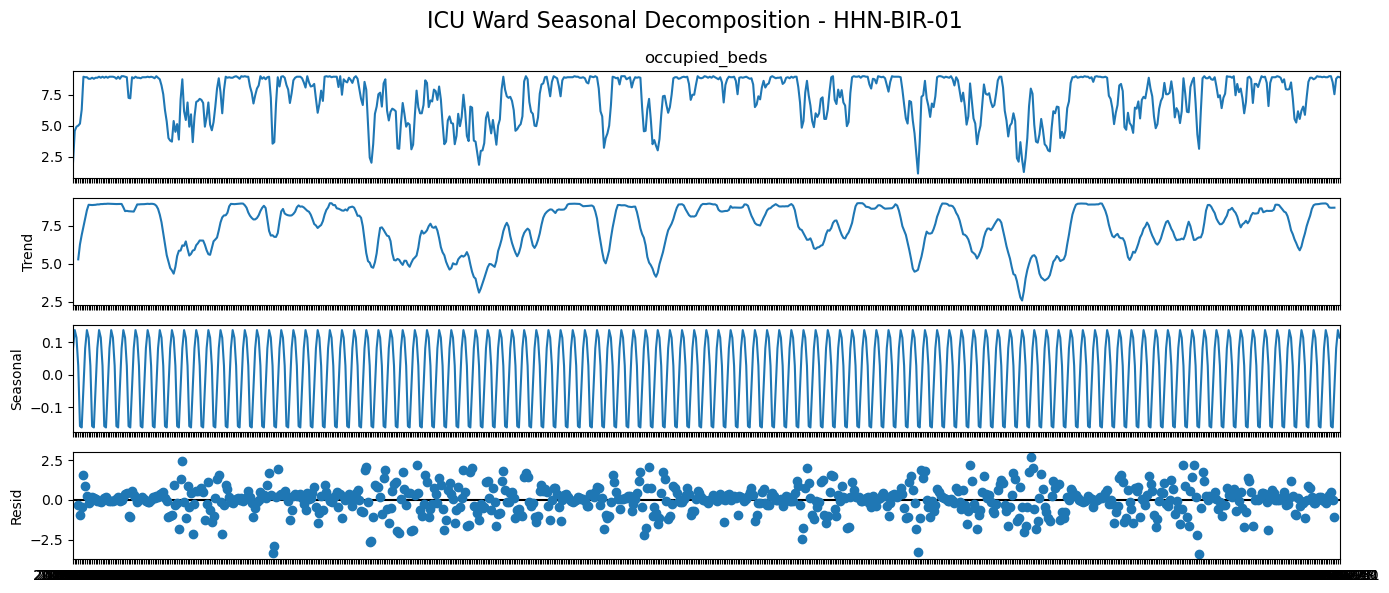

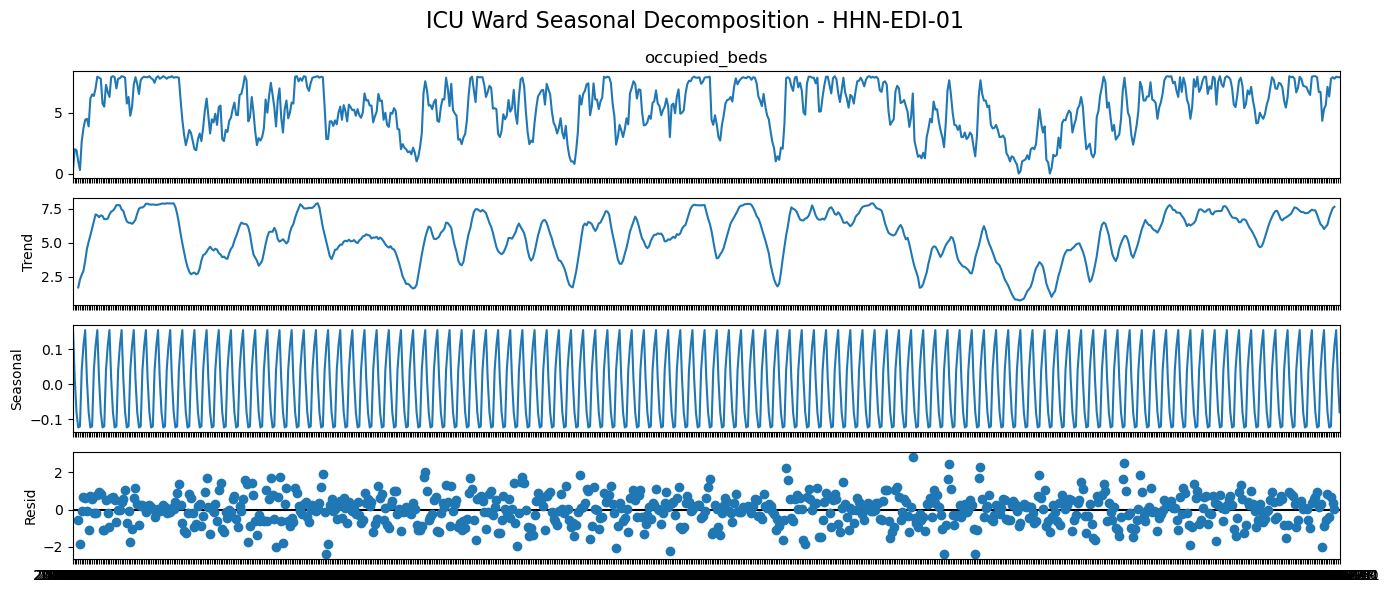

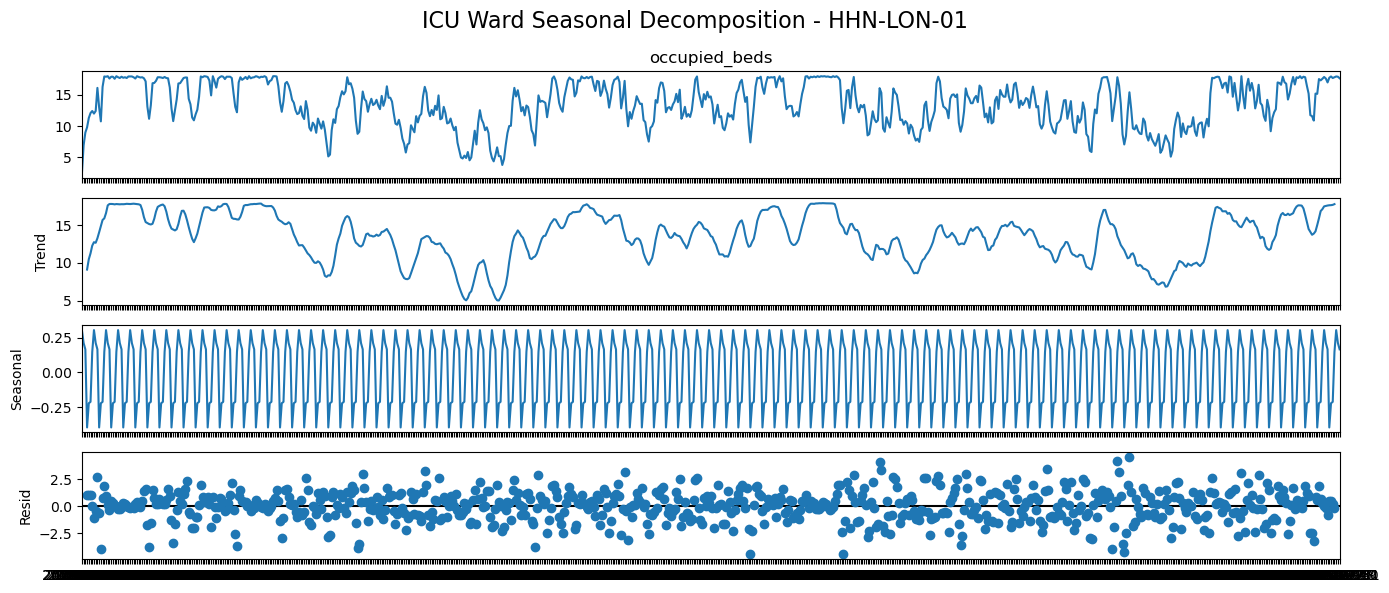

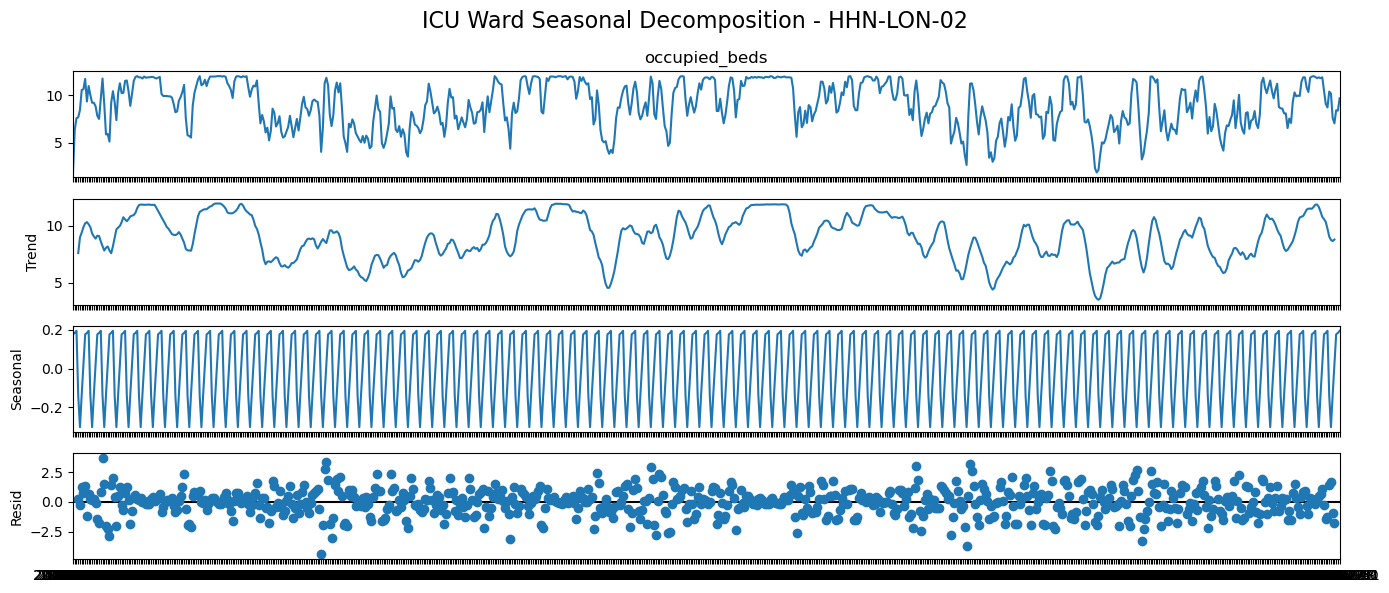

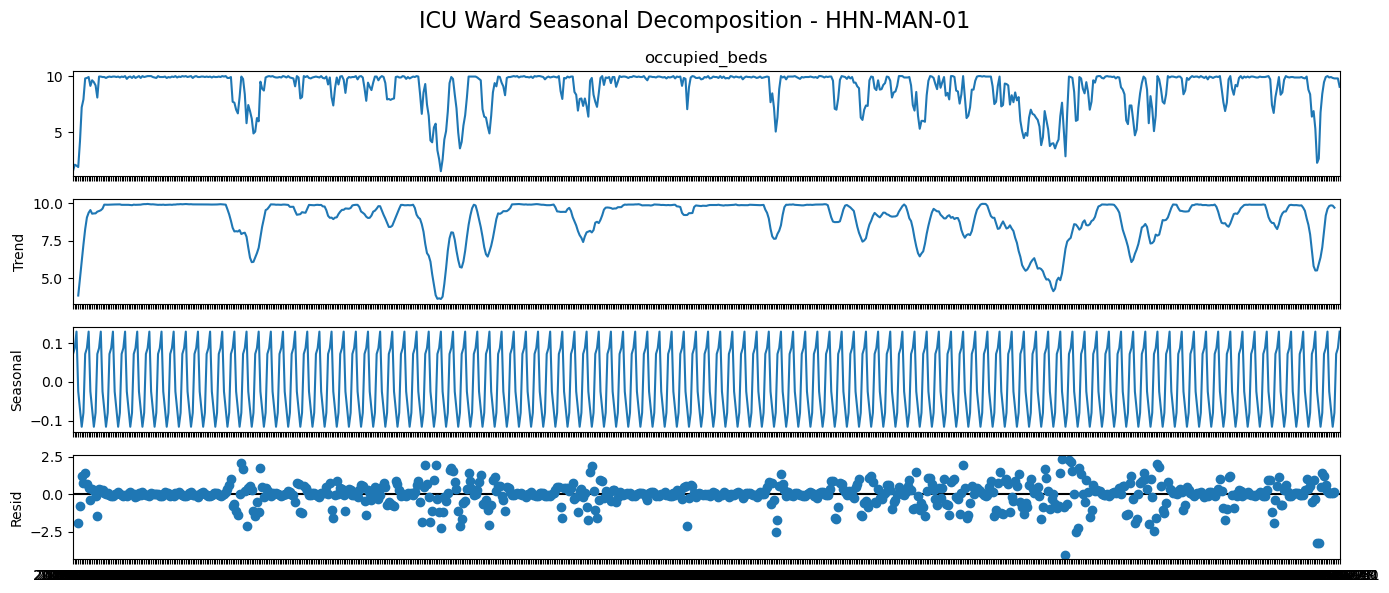

In [25]:
for hospital in sorted(icu["hospital_id"].unique()):

    hospital_data = (icu[icu["hospital_id"] == hospital].sort_values("datetime").set_index("datetime"))
    result = seasonal_decompose(hospital_data["occupied_beds"], model="additive", period=7)
    fig = result.plot()
    fig.set_size_inches(14,6)
    fig.suptitle(f"ICU Ward Seasonal Decomposition - {hospital}", fontsize=16)
    plt.tight_layout()
    plt.show()

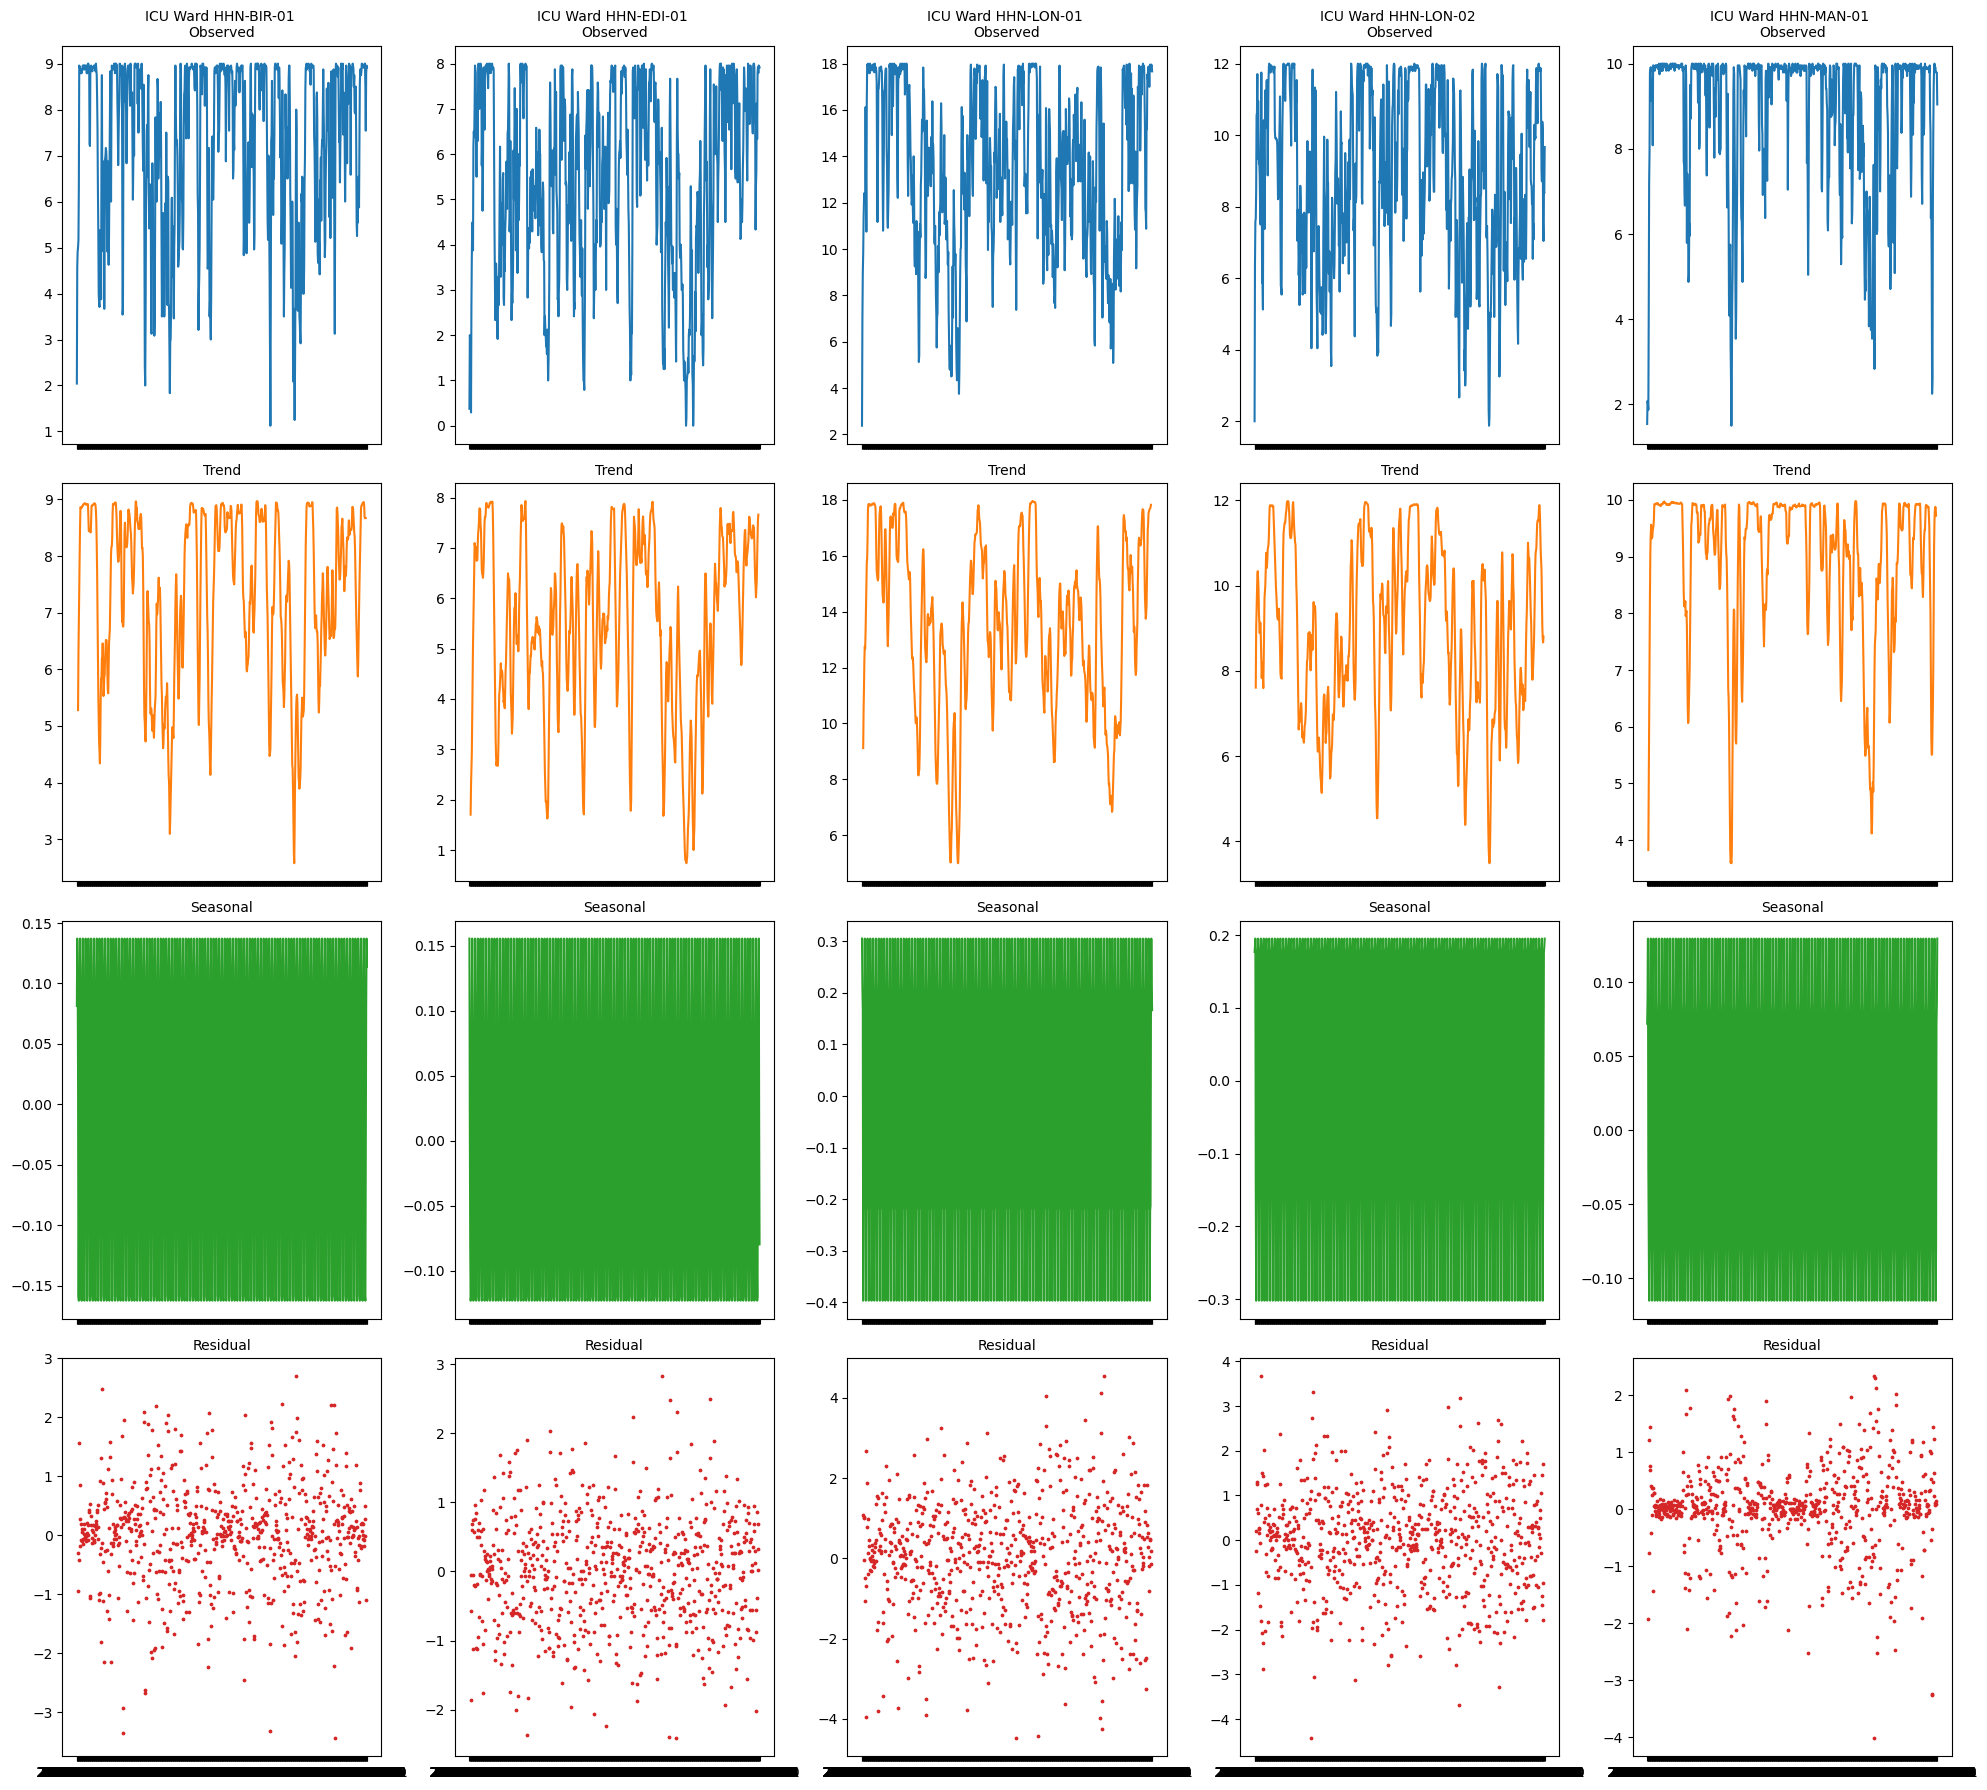

In [27]:
# Create a grid: 4 rows (Observed/Trend/Season/Resid) by X columns (one per hospital)
fig, axes = plt.subplots(4, 5, figsize=(20, 18), sharex=True)

hospitals = sorted(icu["hospital_id"].unique())
for col_idx, hospital in enumerate(hospitals):
    # Filter and decompose data
    hospital_data = icu[icu["hospital_id"] == hospital].sort_values("datetime").set_index("datetime")
    result = seasonal_decompose(hospital_data["occupied_beds"], model="additive", period=7)
    
    # Manually plot each layer into its specific column cell
    axes[0, col_idx].plot(result.observed, color='tab:blue')
    axes[0, col_idx].set_title(f"ICU Ward {hospital} \nObserved", fontsize=10)
    
    axes[1, col_idx].plot(result.trend, color='tab:orange')
    axes[1, col_idx].set_title("Trend", fontsize=10)
    
    axes[2, col_idx].plot(result.seasonal, color='tab:green')
    axes[2, col_idx].set_title("Seasonal", fontsize=10)
    
    axes[3, col_idx].scatter(result.resid.index, result.resid, color='tab:red', s=3)
    axes[3, col_idx].set_title("Residual", fontsize=10)

plt.tight_layout()
plt.show()


     All hospitals frequently operate at or close to maximum bed capacity.
     Long-term trends are the main driver of bed occupancy.
     Seasonal (weekly) patterns are weak and have minimal impact.
     Random, unpredictable events influence bed occupancy more than seasonal cycles.
     The hospitals show similar occupancy behaviour, making a common forecasting approach suitable.
     A standard ARIMA model is more appropriate than a Seasonal ARIMA (SARIMA) model, with predictions capped at each hospital's maximum bed capacity.